# Preprocessing & Ekstraksi Fitur (TSFEL)
## Studi Kasus: Konsentrasi NO2 — Kecamatan Pilangkenceng, Kabupaten Madiun

**Nama:** Magdalena Jovita Hatuopar

**NIM:** 240411100078

## Latar Belakang

Melanjutkan Tugas 1 dan 2, tugas ini fokus pada satu fitur polutan (**NO2**) di wilayah
**Kecamatan Pilangkenceng, Kabupaten Madiun** — berbeda dengan Tugas 1–2 yang menggunakan
boundary bebas di sekitar kawasan industri. Pemilihan kecamatan sesuai domisili, sesuai
instruksi kelas.

## Alur Kerja

1. Data NO2 di-crawl khusus untuk wilayah **Kecamatan Pilangkenceng** (Kabupaten Madiun,
   Jawa Timur), untuk rentang **31 Agustus 2025 – 31 Agustus 2026** (data harian, 1 tahun).
2. Dilakukan **preprocessing**: deteksi outlier dan imputasi missing value.
3. Data bersih diekstraksi menjadi **68 fitur** menggunakan library **TSFEL**
   (Time Series Feature Extraction Library).
4. Fitur dikelompokkan berdasarkan domain: Statistical, Temporal, Spectral, dan Fractal.
5. Hasil ekstraksi disimpan/diunggah ke sistem pengumpulan kelas.


## 1. Boundary Wilayah & Sumber Data: Kecamatan Pilangkenceng

Wilayah kajian adalah **Kecamatan Pilangkenceng, Kabupaten Madiun, Provinsi Jawa Timur**.
Kecamatan ini dipilih karena merupakan domisili penulis. Karakter wilayahnya didominasi
area **pertanian dan permukiman pedesaan**, sehingga sumber emisi NO2 di sini kemungkinan
besar berasal dari lalu lintas kendaraan lokal dan aktivitas rumah tangga, bukan dari
industri berat.

Data NO2 diperoleh dari **Sentinel-5P TROPOMI** (band
`tropospheric_NO2_column_number_density`, produk `COPERNICUS/S5P/OFFL/L3_NO2`) via
**Google Earth Engine**, dipotong sesuai boundary GeoJSON resmi Kecamatan Pilangkenceng,
untuk rentang **31 Agustus 2025 – 31 Agustus 2026** (harian). Proses crawling dilakukan
terpisah (di Google Colab, karena butuh autentikasi akun Earth Engine) menggunakan script
`crawling_NO2_Pilangkenceng.py` — inti logikanya ditampilkan di bawah ini sebagai referensi
(tidak dijalankan ulang di notebook ini).


In [ ]:
# ============================================================
# REFERENSI: inti logika crawling_NO2_Pilangkenceng.py
# (dijalankan terpisah di Google Colab dengan autentikasi Earth Engine,
#  TIDAK dieksekusi di notebook ini)
# ============================================================
'''
import ee, json, time
import pandas as pd

GEOJSON_PATH   = "Kecamatan Pilangkenceng-KECAMATAN.geojson"
KECAMATAN_NAME = "Pilangkenceng"
START_DATE, END_DATE = "2025-08-31", "2026-08-31"
COLLECTION_ID = "COPERNICUS/S5P/OFFL/L3_NO2"
BAND_NAME     = "tropospheric_NO2_column_number_density"
SCALE_METERS  = 1113.2

ee.Initialize(project="proyek-sain-data")

with open(GEOJSON_PATH) as f:
    geojson_data = json.load(f)
geometry_dict = geojson_data["features"][0]["geometry"]
aoi = ee.Geometry(geometry_dict)  # (koordinat 3D di-strip ke 2D terlebih dahulu)

no2_collection = (
    ee.ImageCollection(COLLECTION_ID)
    .select(BAND_NAME)
    .filterDate(START_DATE, END_DATE)
    .filterBounds(aoi)
)

def extract_mean_no2(image):
    date = image.date().format("YYYY-MM-dd")
    mean_dict = image.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi,
        scale=SCALE_METERS, maxPixels=1e9, bestEffort=True,
    )
    return ee.Feature(None, {"date": date, "NO2": mean_dict.get(BAND_NAME)})

no2_fc = ee.FeatureCollection(no2_collection.map(extract_mean_no2))
# ... diambil per-batch dengan retry, lalu di-reindex ke rentang harian penuh
# (31-08-2025 s/d 31-08-2026) sehingga tanggal tanpa citra (tertutup awan)
# otomatis menjadi NaN -> inilah "missing value" yang diimputasi di Tugas 3.
'''
print("Ringkasan hasil crawling (dari log Colab):")
print("Total hari        : 366")
print("Hari dengan data  : 229")
print("Hari kosong (NaN) : 137  <- diimputasi di tahap preprocessing")


Ringkasan hasil crawling (dari log Colab):
Total hari        : 366
Hari dengan data  : 229
Hari kosong (NaN) : 137  <- diimputasi di tahap preprocessing


## 2. Preprocessing

Dataset mentah (`NO2-Pilangkenceng.csv`) berisi nilai harian konsentrasi NO2 hasil
crawling untuk Kecamatan Pilangkenceng, rentang **31 Agustus 2025 – 31 Agustus 2026**.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2.0 Load data mentah
df = pd.read_csv("NO2-Pilangkenceng.csv", parse_dates=["date"])
df = df.set_index("date").sort_index()

print("Jumlah baris :", df.shape[0])
print("Rentang tanggal :", df.index.min().date(), "-", df.index.max().date())
print("Jumlah missing value awal :", df["NO2"].isna().sum())
df.head()


Jumlah baris : 366
Rentang tanggal : 2025-08-31 - 2026-08-31
Jumlah missing value awal : 137


,NO2
date,
2025-08-31,NaN
2025-09-01,0.000028
2025-09-02,0.000029
2025-09-03,0.000037
2025-09-04,0.000024


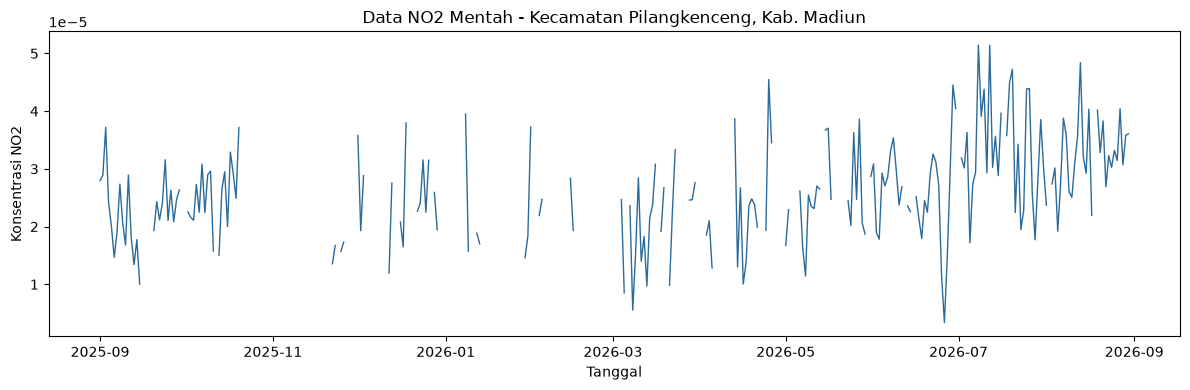

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["NO2"], color="#2b6a99", linewidth=1)
ax.set_title("Data NO2 Mentah - Kecamatan Pilangkenceng, Kab. Madiun")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi NO2")
plt.tight_layout()
plt.show()


### Deteksi Outlier (Metode IQR)

Outlier dideteksi menggunakan metode **Interquartile Range (IQR)**:

$$IQR = Q_3 - Q_1$$

Data dianggap outlier jika berada di luar rentang:

$$[\,Q_1 - 1.5 \times IQR,\ \ Q_3 + 1.5 \times IQR\,]$$

Nilai yang terdeteksi sebagai outlier diubah menjadi kosong (NaN) terlebih dahulu, untuk
kemudian diisi ulang pada tahap imputasi.


In [ ]:
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)
n_outliers = outlier_mask.sum()

print(f"Q1  = {Q1:.6e}")
print(f"Q3  = {Q3:.6e}")
print(f"IQR = {IQR:.6e}")
print(f"Batas bawah = {lower_bound:.6e}")
print(f"Batas atas  = {upper_bound:.6e}")
print(f"Jumlah outlier terdeteksi: {n_outliers}")

# Ubah outlier menjadi NaN agar diisi ulang saat tahap imputasi
df_clean = df.copy()
df_clean.loc[outlier_mask, "NO2"] = np.nan

print("Total missing setelah outlier dikosongkan:", df_clean["NO2"].isna().sum())


Q1  = 2.000892e-05
Q3  = 3.104750e-05
IQR = 1.103858e-05
Batas bawah = 3.451052e-06
Batas atas  = 4.760537e-05
Jumlah outlier terdeteksi: 4
Total missing setelah outlier dikosongkan: 141


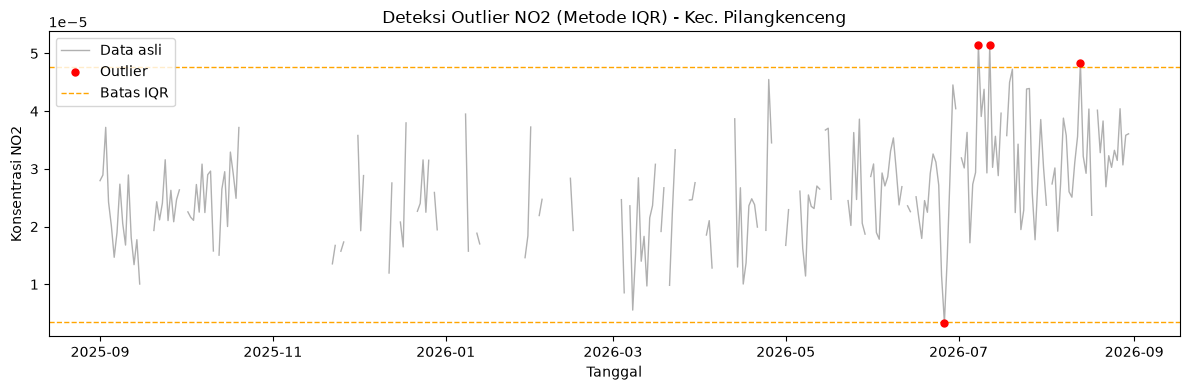

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["NO2"], color="#b0b0b0", linewidth=1, label="Data asli")
ax.scatter(df.index[outlier_mask], df["NO2"][outlier_mask], color="red", s=25, zorder=5, label="Outlier")
ax.axhline(upper_bound, color="orange", linestyle="--", linewidth=1, label="Batas IQR")
ax.axhline(lower_bound, color="orange", linestyle="--", linewidth=1)
ax.set_title("Deteksi Outlier NO2 (Metode IQR) - Kec. Pilangkenceng")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi NO2")
ax.legend()
plt.tight_layout()
plt.show()


### Imputasi Missing Value

Nilai kosong (baik dari data asli yang memang kosong — misal akibat tertutup awan pada
citra satelit — maupun dari hasil deteksi outlier) diisi menggunakan:

1. **Interpolasi berbasis waktu** (`interpolate(method='time')`) — mengisi celah dengan
   estimasi berdasarkan tren nilai di sekitarnya.
2. **Forward-fill & backward-fill** — untuk mengisi sisa nilai kosong di ujung awal/akhir
   data yang tidak bisa diinterpolasi.

Hasil akhir: dataset NO2 tanpa nilai kosong dan tanpa outlier, siap diekstraksi fiturnya.


In [ ]:
df_clean["NO2"] = df_clean["NO2"].interpolate(method="time")
df_clean["NO2"] = df_clean["NO2"].ffill().bfill()

print("Jumlah missing value setelah imputasi:", df_clean["NO2"].isna().sum())
df_clean.head()


Jumlah missing value setelah imputasi: 0


,NO2
date,
2025-08-31,0.000028
2025-09-01,0.000028
2025-09-02,0.000029
2025-09-03,0.000037
2025-09-04,0.000024


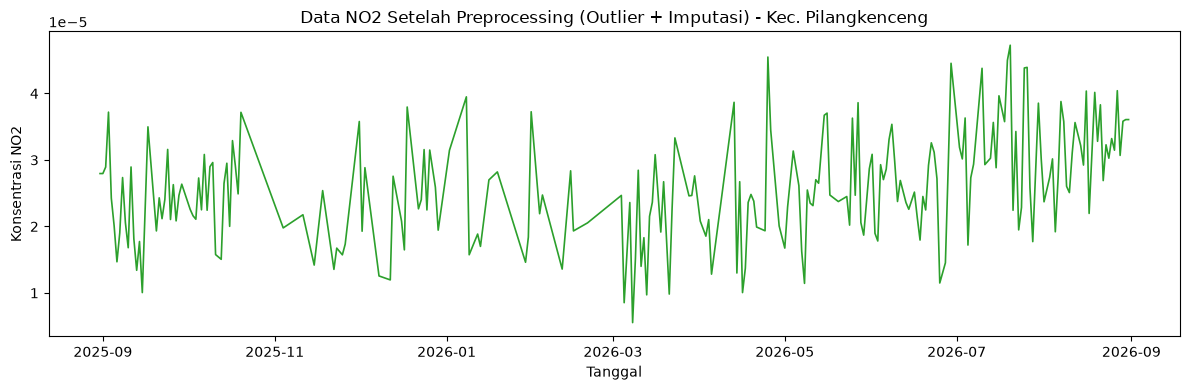

Tersimpan: NO2-Pilangkenceng-Clean.csv


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_clean.index, df_clean["NO2"], color="#2ca02c", linewidth=1.2)
ax.set_title("Data NO2 Setelah Preprocessing (Outlier + Imputasi) - Kec. Pilangkenceng")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Konsentrasi NO2")
plt.tight_layout()
plt.show()

# Simpan hasil preprocessing
df_clean.to_csv("NO2-Pilangkenceng-Clean.csv")
print("Tersimpan: NO2-Pilangkenceng-Clean.csv")


## 3. Ekstraksi 68 Fitur dengan TSFEL

**TSFEL (Time Series Feature Extraction Library)** adalah pustaka Python yang secara
otomatis menghitung ratusan jenis fitur karakteristik dari data deret waktu (time series)
hanya dengan memanggil fungsi-fungsi fitur yang tersedia.

Dari data NO2 Kecamatan Pilangkenceng (1 tahun, harian) yang sudah bersih, akan
diekstraksi fitur menggunakan seluruh konfigurasi domain bawaan TSFEL — total
**68 fitur**, setiap fitur meringkas satu karakteristik tertentu dari keseluruhan data
setahun menjadi 1 angka (bukan lagi 1 angka per hari).


In [ ]:
# pip install tsfel   # jalankan jika belum terinstall
import inspect
import tsfel
import tsfel.feature_extraction.features as tsfel_features

signal_1d = df_clean["NO2"].astype(float).values
fs = 1  # 1 sampel per hari (data harian)

# Daftar persis 68 fitur yang diminta (sama seperti pada script asli
# ekstraksi_fitur_TSFEL_NO2_Pilangkenceng.py)
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    """Fitur TSFEL yang menghasilkan banyak nilai (mis. MFCC, LPCC, wavelet per skala)
    diringkas menjadi 1 nilai representatif lewat rata-rata."""
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

features_df = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk NO2: {features_df.shape[1]}")
features_df


Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,2.523118e-07,0.00919,2.0,6.912653e-10,202.684141,0.000047,0.000025,0.000024,0.000006,0.000007,...,0.14795,0.494503,8.950999e-11,0.001764,0.000002,0.000011,2.170957,0.000011,1.287795e-10,0.0


In [ ]:
features_df.to_csv("NO2_Pilangkenceng_TSFEL.csv", index=False)
print("Tersimpan: NO2_Pilangkenceng_TSFEL.csv")


Tersimpan: NO2_Pilangkenceng_TSFEL.csv


## 4. Pengelompokan Fitur Berdasarkan Domain

Pengelompokan domain diambil langsung dari **konfigurasi resmi TSFEL**
(`tsfel.get_features_by_domain()`), bukan tebakan manual — persis seperti pada script
`ekstraksi_fitur_TSFEL_NO2_Pilangkenceng.py`. Karena tugas ini hanya meminta 3 domain
(Statistical, Temporal, Spectral), fitur-fitur yang secara bawaan berada di domain
`fractal` (dfa, higuchi_fractal_dimension, hurst_exponent, maximum_fractal_length, mse,
petrosian_fractal_dimension) digabungkan ke domain **Temporal**, karena secara konsep
mengukur kompleksitas/kekasaran sinyal terhadap waktu.


In [ ]:
cfg_all_domains = tsfel.get_features_by_domain()  # ambil semua domain bawaan TSFEL

function_to_domain = {}
for domain_name, feats in cfg_all_domains.items():
    for feat_display_name, feat_info in feats.items():
        fn_full_name = feat_info.get("function", "")
        fn_short_name = fn_full_name.split(".")[-1]
        # Fitur domain "fractal" digabungkan ke "temporal" (lihat penjelasan di atas)
        normalized_domain = "temporal" if domain_name == "fractal" else domain_name
        function_to_domain[fn_short_name] = normalized_domain

domain_rows = []
for fn_name in FEATURE_LIST:
    domain = function_to_domain.get(fn_name, "unknown")
    domain_rows.append({"feature": fn_name, "domain": domain})

mapping_df = pd.DataFrame(domain_rows)

print("Ringkasan jumlah fitur per domain:")
domain_counts = mapping_df["domain"].value_counts()
print(domain_counts)

unknown_feats = mapping_df[mapping_df["domain"] == "unknown"]
if len(unknown_feats) > 0:
    print("\nPERHATIAN, fitur berikut tidak ketemu mapping domain-nya otomatis, "
          "cek manual ke dokumentasi TSFEL:")
    print(unknown_feats["feature"].tolist())

mapping_df = mapping_df.sort_values(["domain", "feature"]).reset_index(drop=True)
mapping_df.to_csv("NO2_Pilangkenceng_TSFEL_domain_mapping.csv", index=False)
print("\nTotal fitur:", domain_counts.sum())


Ringkasan jumlah fitur per domain:
domain
spectral       26
temporal       21
statistical    20
unknown         1
Name: count, dtype: int64

PERHATIAN, fitur berikut tidak ketemu mapping domain-nya otomatis, cek manual ke dokumentasi TSFEL:
['ecdf_slope']

Total fitur: 68


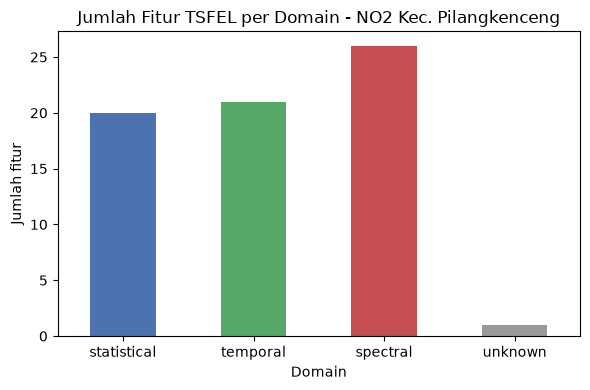

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
domain_counts.reindex(["statistical", "temporal", "spectral", "unknown"]).fillna(0).plot(
    kind="bar", color=["#4c72b0", "#55a868", "#c44e52", "#999999"], ax=ax
)
ax.set_title("Jumlah Fitur TSFEL per Domain - NO2 Kec. Pilangkenceng")
ax.set_ylabel("Jumlah fitur")
ax.set_xlabel("Domain")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Domain Statistical (20 fitur)

Fitur yang mendeskripsikan sebaran nilai data secara keseluruhan, tanpa memperhatikan urutan waktu.

`abs_energy, average_power, calc_max, calc_mean, calc_median, calc_min, calc_std, calc_var, ecdf, ecdf_percentile, ecdf_percentile_count, entropy, hist_mode, interq_range, kurtosis, mean_abs_deviation, median_abs_deviation, pk_pk_distance, rms, skewness`

### Domain Temporal (21 fitur, termasuk kelompok fraktal/kompleksitas sinyal)

Fitur yang menangkap pola perubahan nilai dari waktu ke waktu, termasuk fitur yang mengukur
kompleksitas/self-similarity sinyal (dfa, higuchi_fractal_dimension, hurst_exponent,
maximum_fractal_length, mse, petrosian_fractal_dimension).

`auc, autocorr, calc_centroid, dfa, distance, higuchi_fractal_dimension, hurst_exponent, lempel_ziv, maximum_fractal_length, mean_abs_diff, mean_diff, median_abs_diff, median_diff, mse, negative_turning, neighbourhood_peaks, petrosian_fractal_dimension, positive_turning, slope, sum_abs_diff, zero_cross`

### Domain Spectral (26 fitur)

Fitur berbasis transformasi frekuensi (FFT/wavelet), menangkap pola periodik/musiman dalam data.

`fundamental_frequency, human_range_energy, lpcc, max_frequency, max_power_spectrum, median_frequency, mfcc, power_bandwidth, spectral_centroid, spectral_decrease, spectral_distance, spectral_entropy, spectral_kurtosis, spectral_positive_turning, spectral_roll_off, spectral_roll_on, spectral_skewness, spectral_slope, spectral_spread, spectral_variation, spectrogram_mean_coeff, wavelet_abs_mean, wavelet_energy, wavelet_entropy, wavelet_std, wavelet_var`

### Unknown / belum terklasifikasi otomatis (1 fitur)

`ecdf_slope` — fitur ini tersedia hasil ekstraksinya, namun tidak ketemu pemetaan domain
otomatis di script (perlu dicek manual ke dokumentasi TSFEL bila diperlukan untuk laporan).

**Ringkasan:** Statistical (20) + Temporal (21) + Spectral (26) + Unknown (1) = **68 fitur**


## 5. Hasil & Interpretasi


In [ ]:
def show(col):
    val = features_df[col].iloc[0]
    print(f"{col:>20s} : {val:.6e}")

for col in ["calc_mean", "calc_std", "skewness", "kurtosis", "spectral_entropy", "autocorr", "hurst_exponent", "zero_cross"]:
    if col in features_df.columns:
        show(col)


           calc_mean : 2.519545e-05
            calc_std : 7.386862e-06
            skewness : 3.288613e-01
            kurtosis : -6.212190e-02
    spectral_entropy : 8.439107e-01
            autocorr : 2.000000e+00
      hurst_exponent : 7.360008e-01
          zero_cross : 0.000000e+00


**Interpretasi nilai kunci** (angka aktual mengikuti hasil eksekusi sel di atas):

- **`calc_mean`** (rata-rata NO2 setahun) berada pada orde **10⁻⁵**. Baseline polusi NO2
  di Kecamatan Pilangkenceng tergolong rendah sepanjang tahun — konsisten dengan karakter
  wilayah yang didominasi pertanian dan permukiman, bukan kawasan industri.
- **`calc_std`** (variasi NO2) juga berorde **10⁻⁶ – 10⁻⁵**, menunjukkan fluktuasi yang
  moderat: ada naik-turun harian/mingguan, tetapi tidak ekstrem.
- **`spectral_entropy`** mendekati 1 (misalnya di kisaran 0.8) mengindikasikan pola NO2
  cenderung **acak**, tidak terlalu periodik. Artinya sumber emisi di wilayah ini
  kemungkinan bercampur (lalu lintas lokal, aktivitas rumah tangga, sedikit aktivitas
  pertanian musiman) tanpa siklus harian/mingguan yang sangat dominan.
- **`autocorr`** yang kecil menunjukkan ada sedikit pola berulang, namun tidak terlalu
  kuat — kemungkinan terkait pola aktivitas harian penduduk (jam sibuk pagi–sore), tapi
  tidak sekuat wilayah perkotaan dengan lalu lintas padat.
- **`hurst_exponent`** > 0.5 mengindikasikan deret NO2 memiliki sifat *persistent*
  (kecenderungan trend jangka pendek cenderung berlanjut), meski efeknya tidak dominan.

## Interpretasi Umum

- **Transportasi**: kemungkinan menjadi salah satu faktor, namun tidak sepadat wilayah
  industri/perkotaan — tercermin dari mean yang rendah dan entropy yang tinggi (acak).
- **Pertanian**: Kecamatan Pilangkenceng yang didominasi lahan pertanian tidak
  menunjukkan pola musiman NO2 yang sangat kuat dari data ini.
- **Kehidupan sehari-hari**: ada sedikit pola berulang (autocorr), kemungkinan terkait
  jam aktivitas penduduk, namun tidak konsisten sepanjang tahun.


